## What is K-Means Clustering?

K-Means is an **unsupervised machine learning algorithm** used for **clustering**. It aims to partition a dataset into **K distinct, non-overlapping groups** (clusters) based on similarity.

### How it works:
1. **Choose the number of clusters (K)**.
2. **Randomly initialize** K "centroids" (cluster centers).
3. **Assign each data point** to the nearest centroid.
4. **Recalculate** the centroids as the mean of all assigned points.
5. **Repeat** steps 3 and 4 until convergence (centroids stop changing).

The goal is to **minimize the "within-cluster sum of squares"** — the distance between points and their assigned centroids.

K-Means is useful for:
- Customer segmentation
- Image compression
- Market segmentation
- Pattern recognition


In [49]:
# import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [50]:
# load dataset
df = pd.read_csv('/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv')


In [51]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [52]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [53]:
# Use 'Annual Income' and 'Spending Score' for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [54]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [55]:
# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


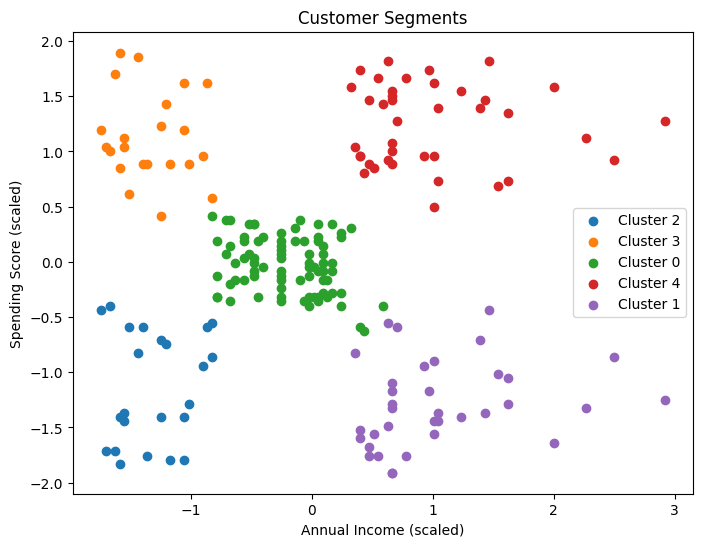

In [56]:
# Plot clusters
plt.figure(figsize=(8,6))
for cluster in df['Cluster'].unique():
    plt.scatter(X_scaled[df['Cluster'] == cluster][:, 0], 
                X_scaled[df['Cluster'] == cluster][:, 1], 
                label=f'Cluster {cluster}')
plt.title("Customer Segments")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.legend()
plt.show()

## PERFORMANCE METRICS

In [57]:
# Inertia (Within-Cluster Sum of Squares): 
# Measures how tightly the data points are grouped within clusters (lower is better)
print ("Inertia: " , kmeans.inertia_)

Inertia:  65.5684081557168


In [58]:
# Silhouette Score:
# Measures how similar a data point is to its own cluster vs. other clusters.
# Range: -1 to 1 (closer to 1 is better)

from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, kmeans.labels_)
print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:8

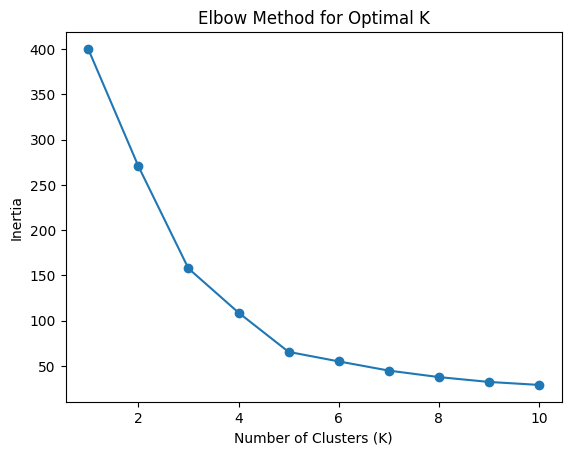

In [59]:
# Elbow Method (to find optimal K):
# Plot inertia vs. K to find the "elbow point" where adding more clusters gives diminishing returns

inertias = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()


# CONCLUSION

## Evaluating Clustering Performance

Since clustering is unsupervised, we use **internal evaluation metrics**:

- **Inertia**: Measures how tightly points are clustered. Lower = better.
- **Silhouette Score**: Measures how well-separated clusters are. Closer to 1 = better.
- **Elbow Method**: Helps find the best K by plotting inertia vs. K.

Use these metrics to justify your choice of `K` and evaluate clustering quality.
